<a href="https://colab.research.google.com/github/Yousef-Zeer/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sales


- Author: Yousef Al Zeer

## Project Overview

## Imports

In [47]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [48]:
from google.colab import drive
drive.mount('/content/drive' , force_remount=True)

Mounted at /content/drive


## Load and Inspect Data

In [49]:
sales_url = "/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv"
df_sales = pd.read_csv(sales_url)

# Preview the first 5 rows
df_sales.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [50]:
# 1 - How many rows and columns?
print(f"The dataset has {df_sales.shape[0]} rows and {df_sales.shape[1]} columns.\n")

# 2 - What are the datatypes ?
print(df_sales.dtypes)

# General info
df_sales.info()

The dataset has 8523 rows and 12 columns.

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 


## Clean Data

### Duplicated Data

In [51]:
# 3 -  Identify and drop duplicates
duplicated_rows = df_sales.duplicated().sum()
print(f"Number of duplicated rows: {duplicated_rows}")

# Drop duplicates (to ensure everything is OK)
df_sales = df_sales.drop_duplicates()

Number of duplicated rows: 0


###  Identify and Adressing Missing Values

Missing values:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


<Axes: >

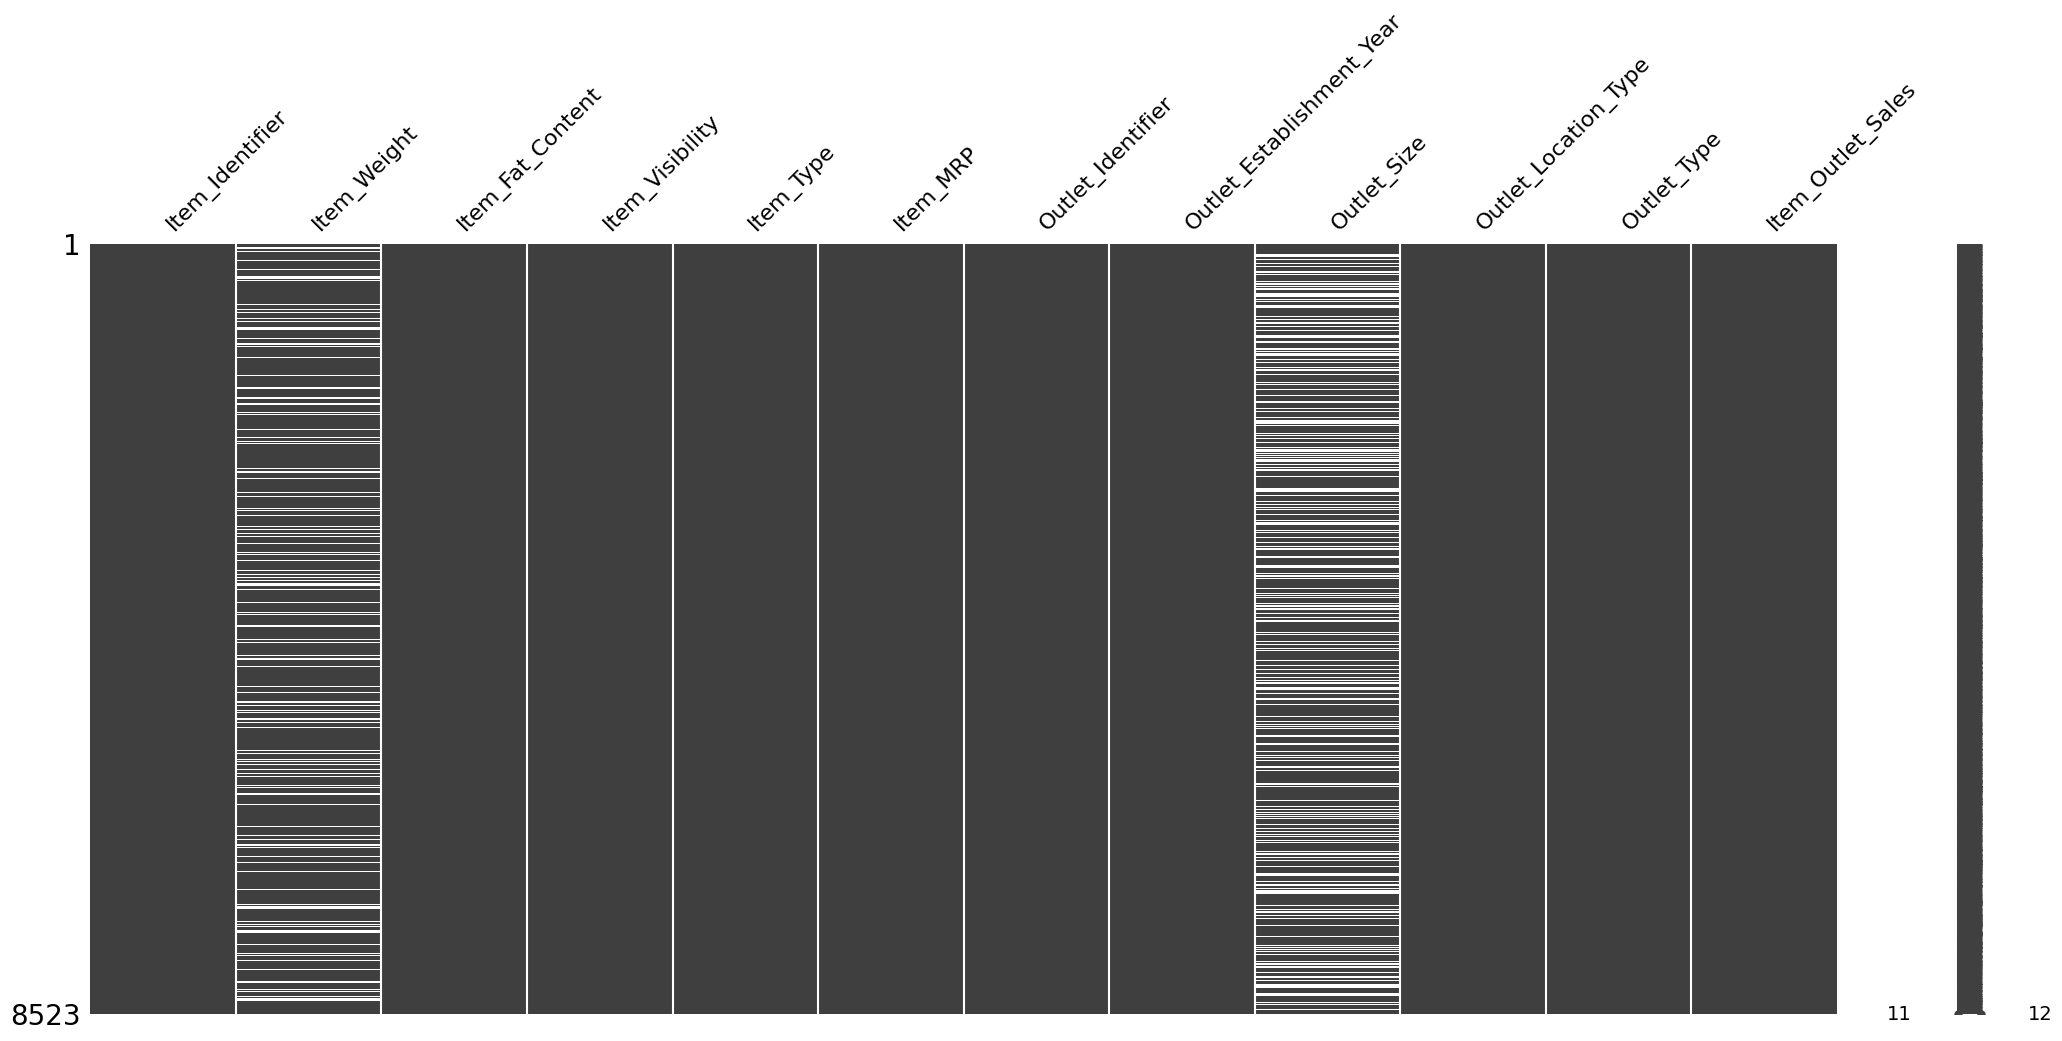

In [52]:
# 4 -  Identify missing values
missing_values = df_sales.isna().sum()
print("Missing values:")
print(missing_values)

# Visualizing missing values
msno.matrix(df_sales)

Identifying % of missing data

In [53]:
df_sales.isna().sum() / len(df_sales) * 100

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


- Missing Values:
  - There are `1463` missing values in the `Item_Weight` column. (17.16%)
  - There are `2410` missing values in the `Outlet_Size` column. (28.27%)

- In order to make accurate decisions, we can perform EDA for each feature and choose an appropriate strategy.

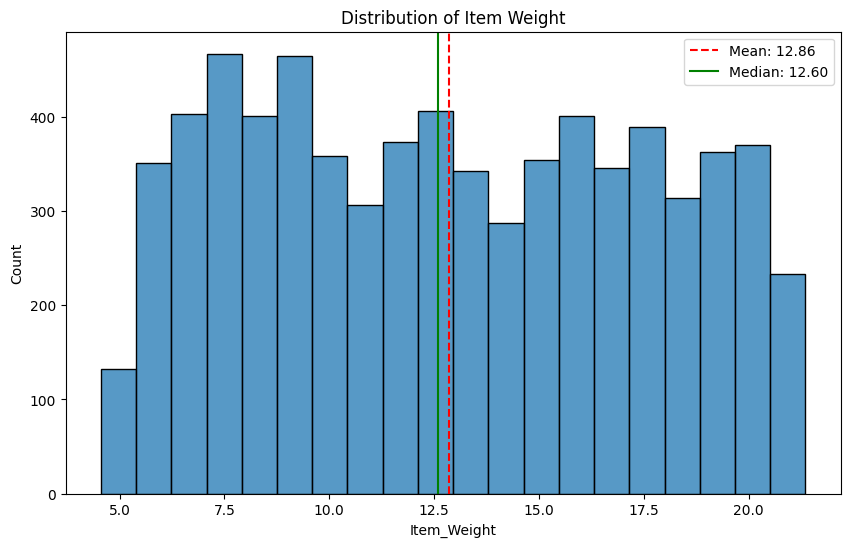

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

mean_val = df_sales['Item_Weight'].mean()
median_val = df_sales['Item_Weight'].median()

sns.histplot(df_sales['Item_Weight'], ax=ax)

ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')

ax.legend()
ax.set_title('Distribution of Item Weight') ;

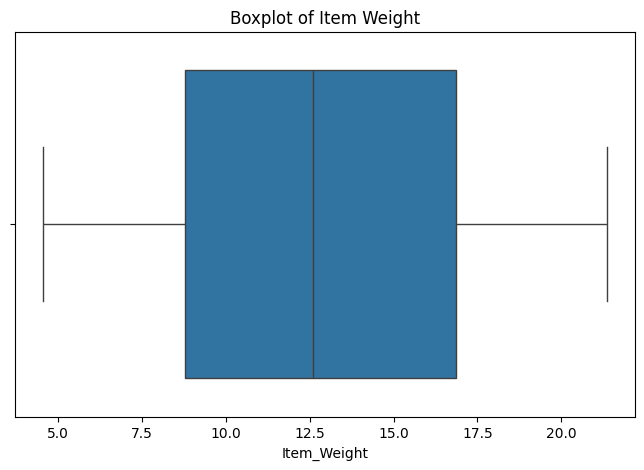

In [55]:
# Using box plot to draw an accurate plot of whether there are outliers ​​that we can't observe in histogram
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=df_sales['Item_Weight'])
ax.set_title('Boxplot of Item Weight') ;

- Preliminary visual analysis confirms  Mean ≈ Median with no significant outliers, validating **"Mean"** imputation as a safe and statistically sound approach.

- I implemented a granular imputation strategy using ***group-wise means*** based on **Item_Identifier** rather than a global mean, ensuring that imputed values reflect actual product characteristics.

In [56]:
# Calculate the mean weight for each specific product identifier
item_weight_mean = df_sales.groupby("Item_Identifier")["Item_Weight"].mean()

# Mapping group-wise means to product-specific traits
df_sales['Item_Weight'] = df_sales['Item_Weight'].fillna(df_sales['Item_Identifier'].map(item_weight_mean))

- Checking to make sure the values for the `Item_Weight` column were filled in.

In [57]:
df_sales['Item_Weight'].isna().sum()

np.int64(4)

- Let's Investigate remaining 4 missing values

In [58]:
missing_items = df_sales.loc[df_sales['Item_Weight'].isna(), 'Item_Identifier'].unique()
missing_items

array(['FDN52', 'FDK57', 'FDE52', 'FDQ60'], dtype=object)

In [59]:
missing_items_details = df_sales.loc[df_sales['Item_Weight'].isna(), ['Item_Identifier', 'Item_Type']]
missing_items_details

,Item_Identifier,Item_Type
927,FDN52,Frozen Foods
1922,FDK57,Snack Foods
4187,FDE52,Dairy
5022,FDQ60,Baking Goods


4 distinct values . Applied a imputation strategy by mapping the **median weight per Item_Type** for the remaining missing values

In [60]:
item_type_median = df_sales.groupby("Item_Type")["Item_Weight"].median()

df_sales['Item_Weight'] = df_sales['Item_Weight'].fillna(df_sales['Item_Type'].map(item_type_median))

In [61]:
df_sales['Item_Weight'].isna().sum()

np.int64(0)

Missing values after cleaning:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


<Axes: >

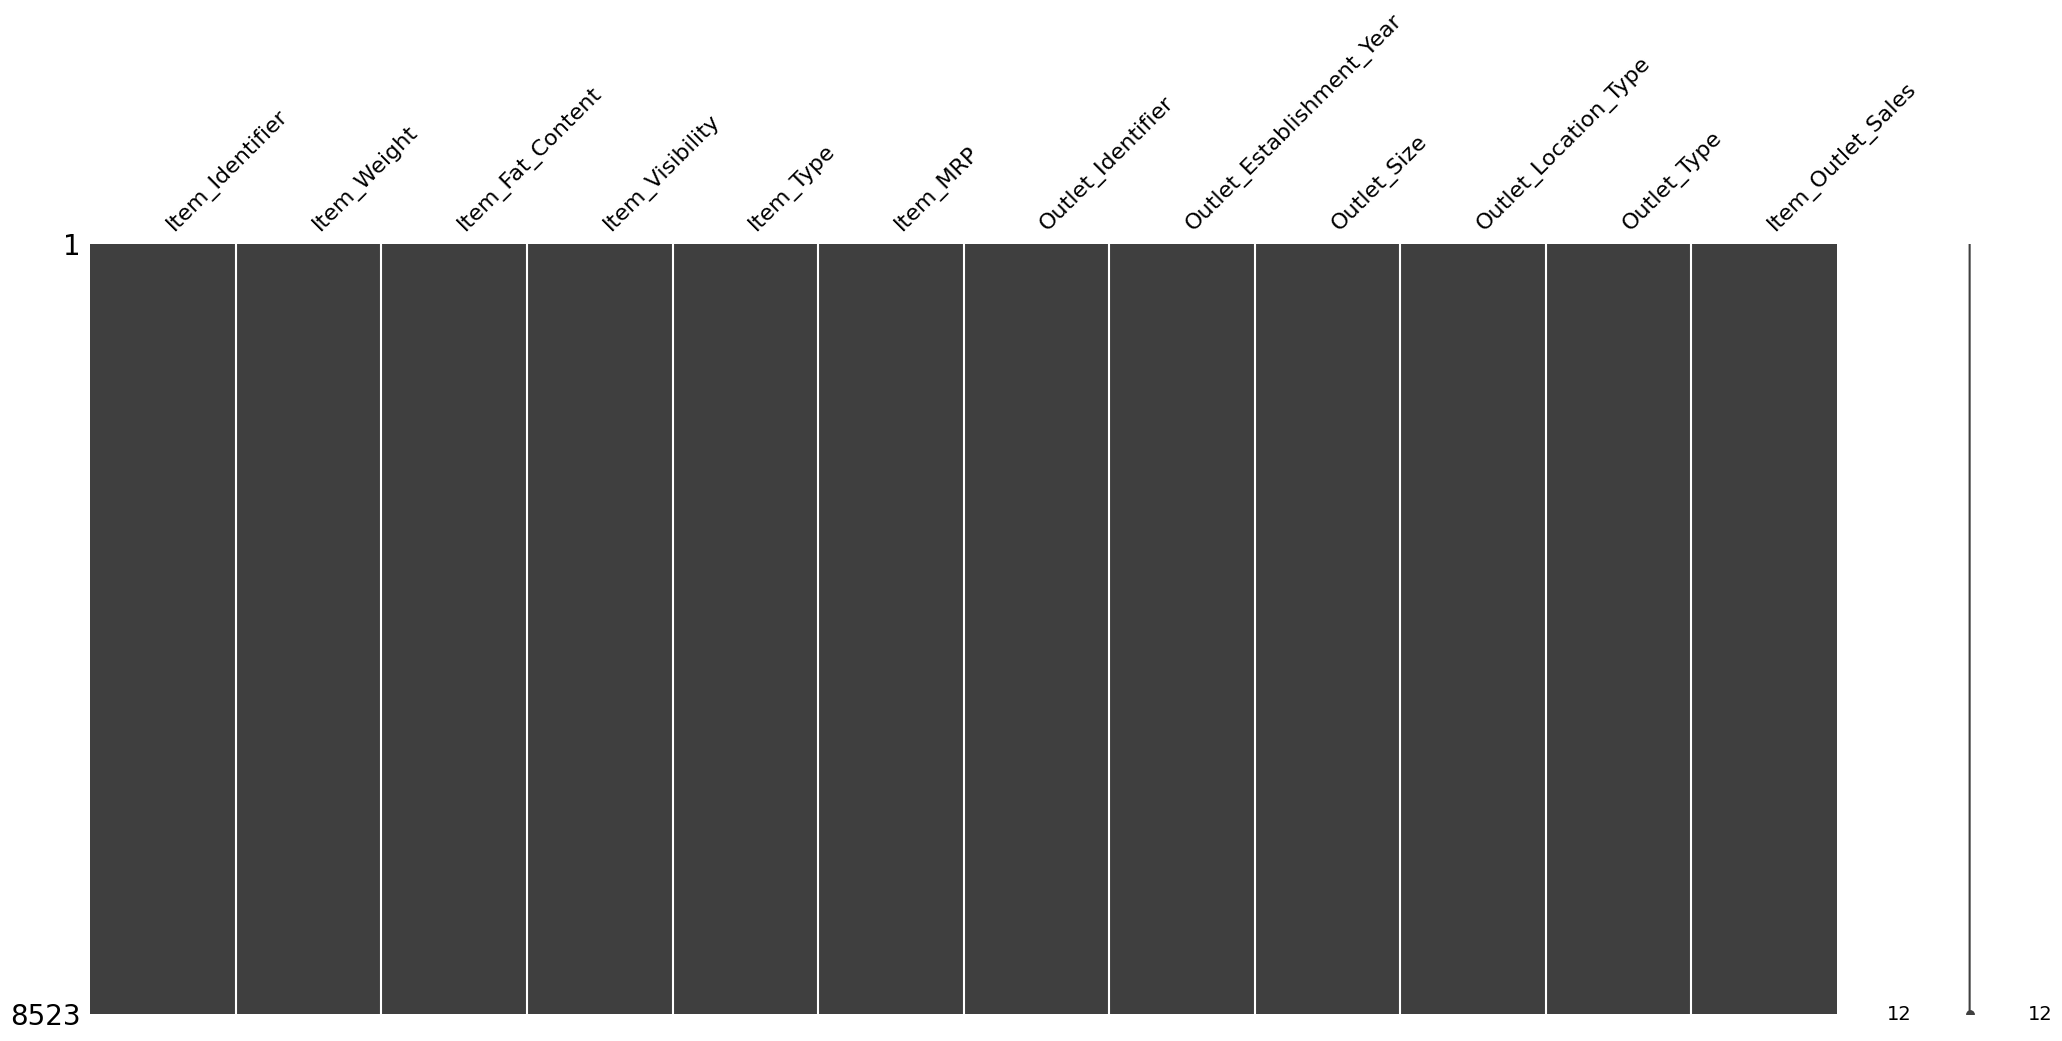

In [62]:
# 5 -  Address missing values by using a placeholder
# Filling numerical missing values
# df_sales['Item_Weight'] = df_sales['Item_Weight'].fillna(-1)

# Filling categorical missing values
df_sales['Outlet_Size'] = df_sales['Outlet_Size'].fillna("MISSING")

# 6 -  Confirm that there are no missing values now
print("Missing values after cleaning:")
print(df_sales.isna().sum())

# visual check
msno.matrix(df_sales)

### Inspecting Categorical Columns & Addressing Inconsistent Values

In [63]:
# Inspecting Categorical columns
cat_cols = df_sales.select_dtypes("object").columns
cat_cols

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [64]:
# for loop that loops through all of the object type columns
for col in cat_cols:
  print(f"Value counts for {col}")
  print(df_sales[col].value_counts())
  print("\n")

Value counts for Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


Value counts for Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


Value counts for Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


Value counts for Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013

In [65]:
# 7 - Find and fix inconsistent categories

print("Before fixing:")
print(df_sales['Item_Fat_Content'].value_counts())


rename_dict = {"LF" : "Low Fat" , "low fat" : "Low Fat" , "reg" : "Regular"}
df_sales['Item_Fat_Content'] = df_sales['Item_Fat_Content'].replace(rename_dict)

print("\nAfter fixing:")
print(df_sales['Item_Fat_Content'].value_counts())

Before fixing:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

After fixing:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


### Summary Statistics for Numeric Feature

In [66]:
df_sales.describe().round(2)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.00,8523.00,8523.00,8523.00,8523.00
mean,12.88,0.07,140.99,1997.83,2181.29
std,4.65,0.05,62.28,8.37,1706.50
min,4.56,0.00,31.29,1985.00,33.29
25%,8.78,0.03,93.83,1987.00,834.25
50%,12.65,0.05,143.01,1999.00,1794.33
75%,16.85,0.09,185.64,2004.00,3101.30
max,21.35,0.33,266.89,2009.00,13086.96


## Exploratory Data Analysis

In [67]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


- For each numeric feature, we will plot the distribution "Histogram" and a boxplot.

In [68]:
num_cols = df_sales.select_dtypes("number").columns
num_cols

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [69]:
def numeric_plot(df_sales, col):
    fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(10, 7))

    mean_val = df_sales[col].mean()
    med_val = df_sales[col].median()

    sns.histplot(data=df_sales, x=col, bins=50, ax=axes[0])

    axes[0].axvline(mean_val, color="red", ls="--", label=f"Mean = {mean_val:.2f}")
    axes[0].axvline(med_val, color="green", ls="-", label=f"Median = {med_val:.2f}")

    sns.boxplot(data=df_sales, x=col, ax=axes[1])
    axes[0].legend()
    axes[0].set_title(f'Distribution for {col}' , fontweight="bold")
    plt.tight_layout()
    plt.show()

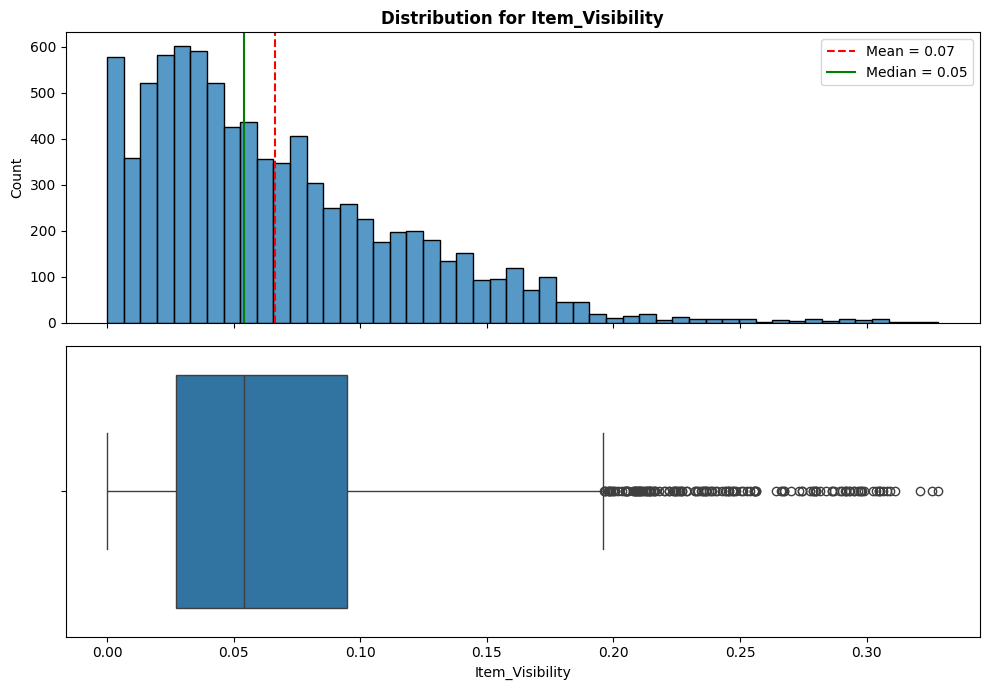

In [70]:
numeric_plot(df_sales , "Item_Visibility")

- Looking at histogram and boxplot, it is clear that Item_Visibility is right-skewed, meaning the vast majority of products receive very little display space (between 0 and 0.05)

- boxplot shows several outliers on the right side of the distribution. These represent products with high visibility compared to the rest of the items.



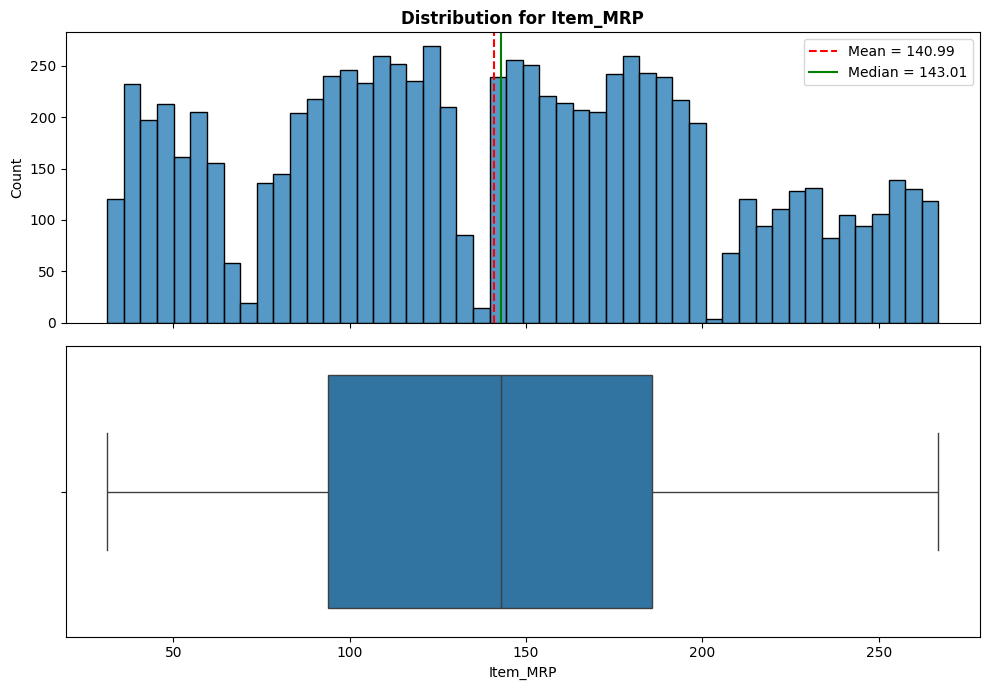

In [71]:
numeric_plot(df_sales , "Item_MRP")

- Looking at histogram and boxplot, Item MRP distribution is multimodal ( 4 prices categories ) , indicating that the store has distinct pricing tiers for its products.

- mean (140.99) and median (143.01) are very close, showing that pricing is balanced and doesnt have significant skewness.

- boxplot shows no outliers, which confirms that all product prices fall within a normal range for the store.

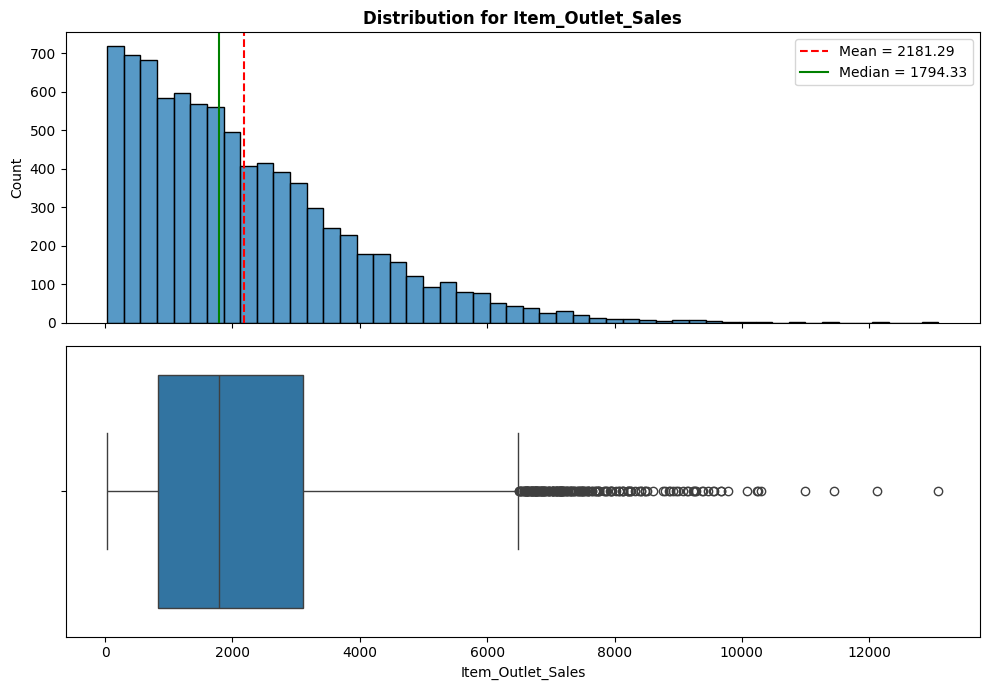

In [72]:
numeric_plot(df_sales , "Item_Outlet_Sales")

- Distribution of Item_Outlet_Sales is right-skewed, showing that the majority of products have relatively low sales.

- boxplot displays numerous outliers on the right, which represent high-performing products that significantly drive up the average sales.

- Since these outliers represent successful products (high sales), they are valid data points and should be kept

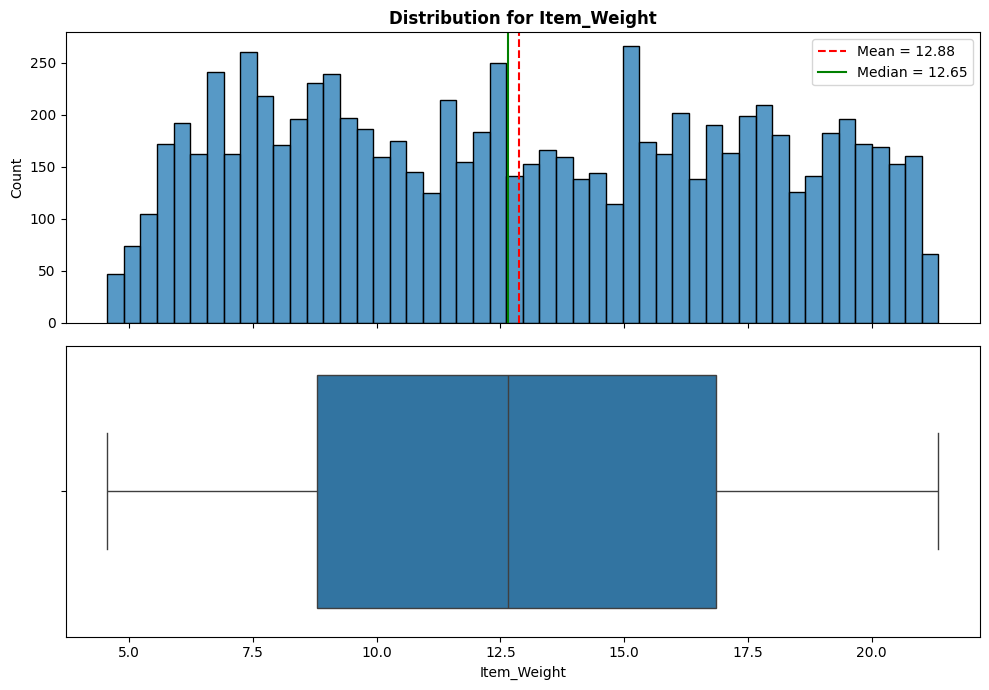

In [73]:
numeric_plot(df_sales , "Item_Weight")

- Distribution of Item_Weight is remarkably symmetric, showing no significant skewness.

- mean (12.88) and median (12.65) are very close, confirms the balance of the data.

- boxplot shows a balanced spread of data without any outliers, Displays a consistent variety of product weights.

In [74]:
cat_cols = df_sales.select_dtypes("object").columns
cat_cols

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [75]:
def cat_analysis_plot(data, x, y, title):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    order = data[x].value_counts().index
    sns.countplot(data=data, x=x, ax=axes[0], order=order, hue=x, legend=False)
    axes[0].set_title(f"Count of {x}", fontsize=14, fontweight="bold")
    axes[0].tick_params(axis="x", rotation=45)

    sns.boxplot(data=data, x=x, y=y, ax=axes[1], order=order, hue=x, legend=False)
    axes[1].set_title(f"Distribution of {y} by {x}", fontsize=14, fontweight="bold")
    axes[1].tick_params(axis="x", rotation=45)

    plt.suptitle(title, fontsize=18, fontweight="bold")
    plt.tight_layout()

    return fig, axes

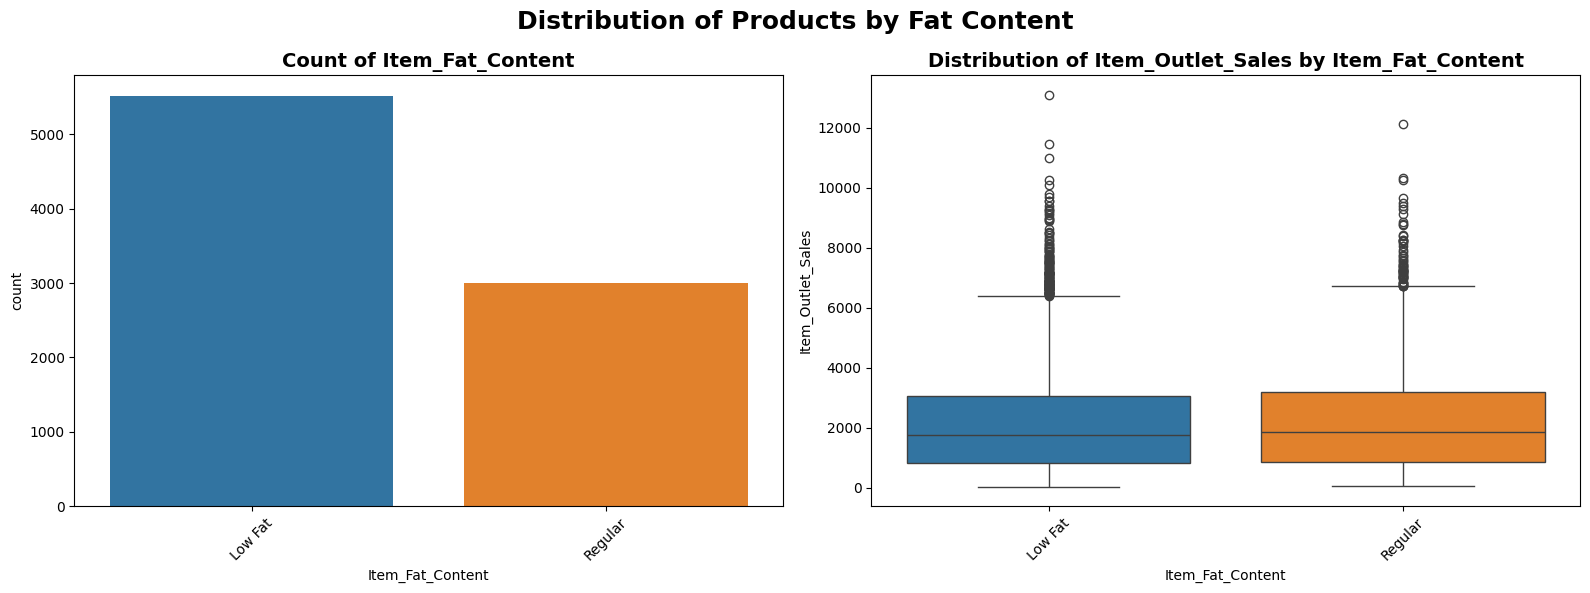

In [76]:
cat_analysis_plot(df_sales, x="Item_Fat_Content", y="Item_Outlet_Sales", title="Distribution of Products by Fat Content") ;

- count plot indicates a clear consumer preference or supply strategy favoring 'Low Fat' products .

- box plot demonstrates that 'Item_Fat_Content' has virtually no influence on 'Item_Outlet_Sales', as median values and overall distribution are nearly identical for both categories.

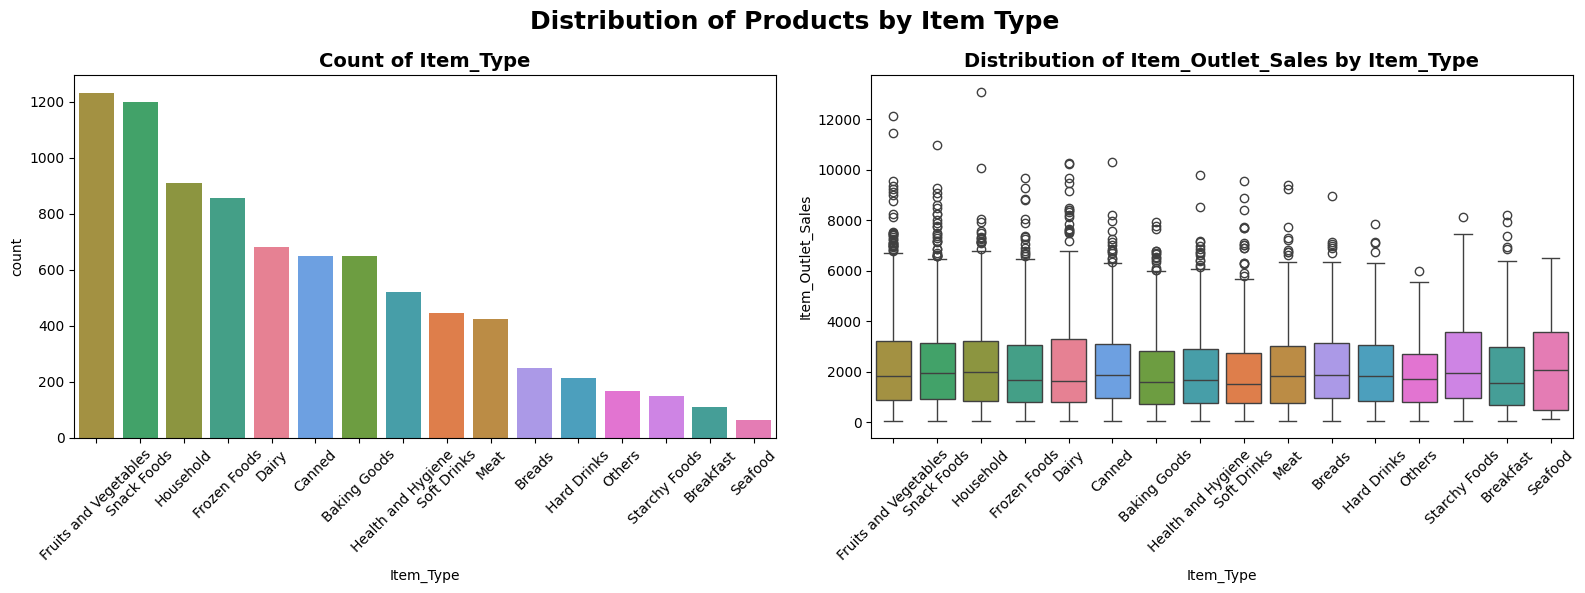

In [77]:
cat_analysis_plot(df_sales, x="Item_Type", y='Item_Outlet_Sales', title='Distribution of Products by Item Type') ;


- count plot shows a clear concentration of stock in 'Fruits and Vegetables' and 'Snack Foods', indicating these are the primary inventory products

- box plot reveals consistent median sales across all item types, suggesting that no single product category significantly outperforms others

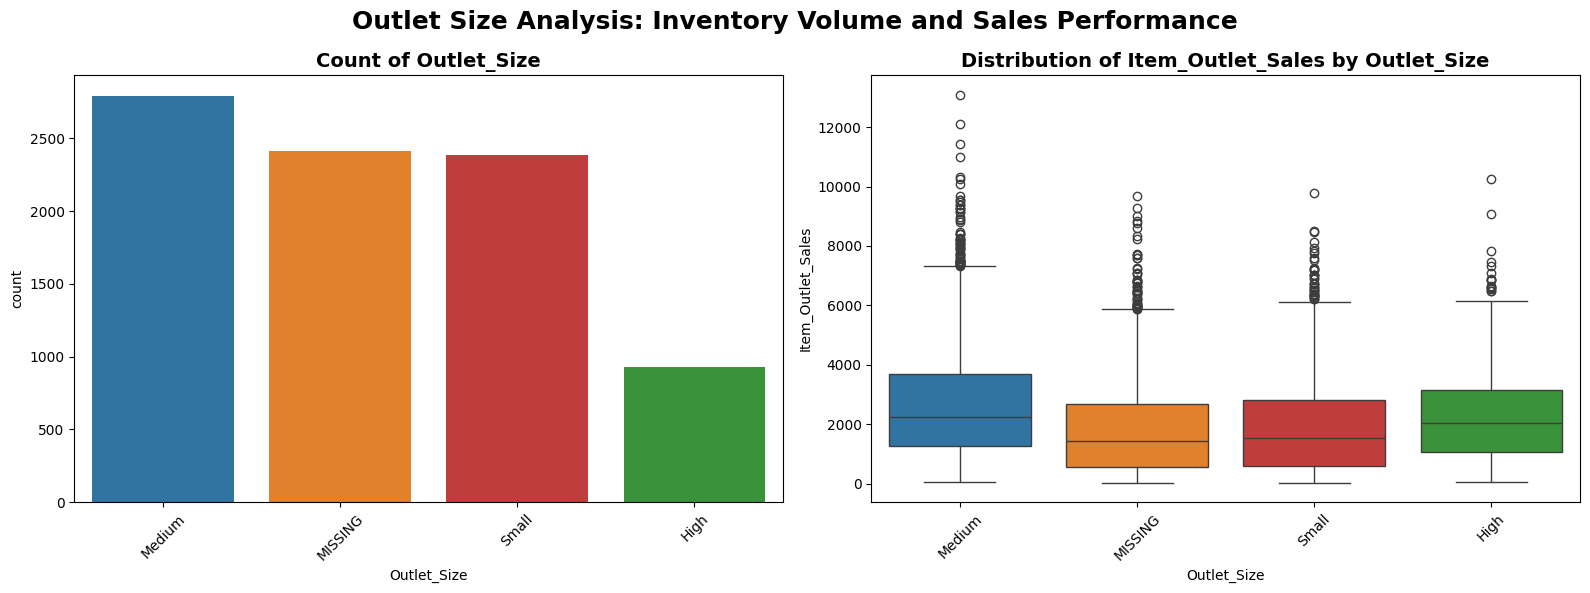

In [78]:
cat_analysis_plot(df_sales, x="Outlet_Size", y='Item_Outlet_Sales', title="Outlet Size Analysis: Inventory Volume and Sales Performance") ;

- count plot identifies 'Medium' as the most prevalent outlet size

- box plot shows that 'High' and 'Medium' size outlets consistently outperform 'Small' outlets in median sales

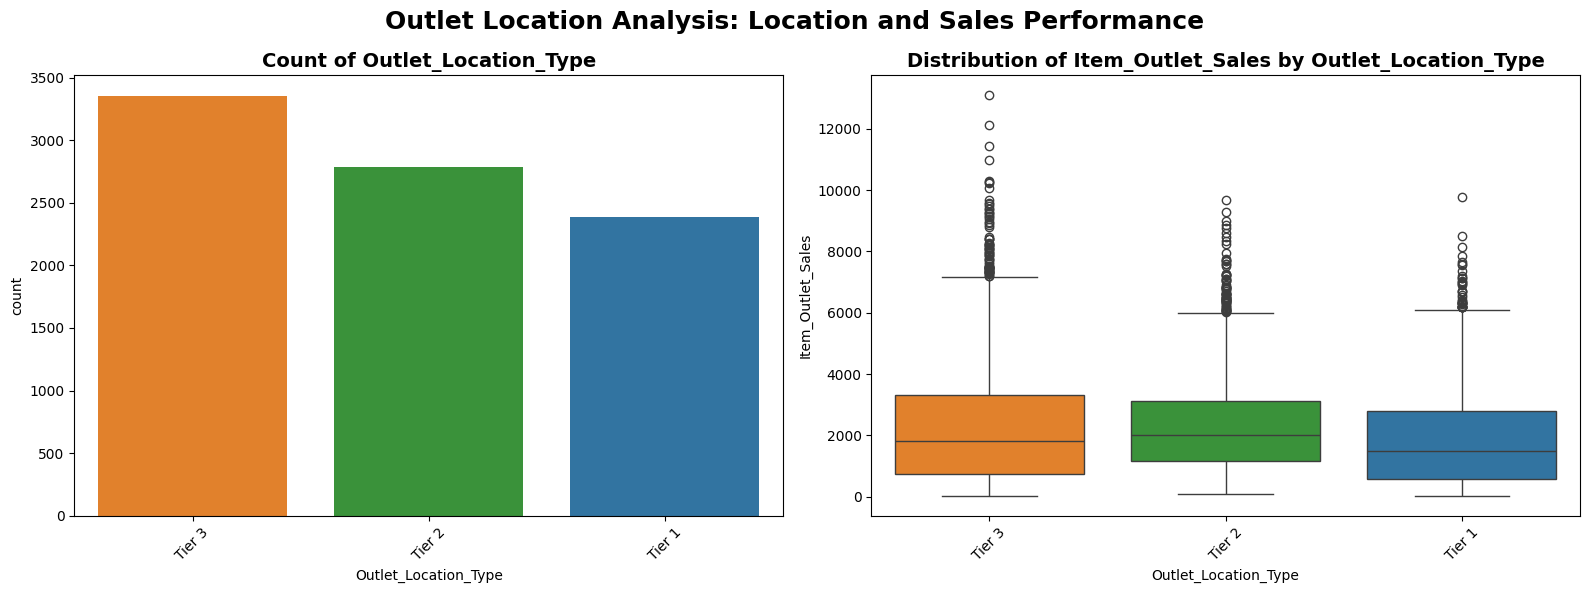

In [79]:
cat_analysis_plot(df_sales, x="Outlet_Location_Type", y='Item_Outlet_Sales', title="Outlet Location Analysis: Location and Sales Performance") ;

- count plot shows that 'Tier 3' locations have the highest presence
-  box plot reveals that 'Tier 2 achieve the highest median sales, followed by 'Tier1' .Tier 3 displays a broader distribution of extreme sales values,

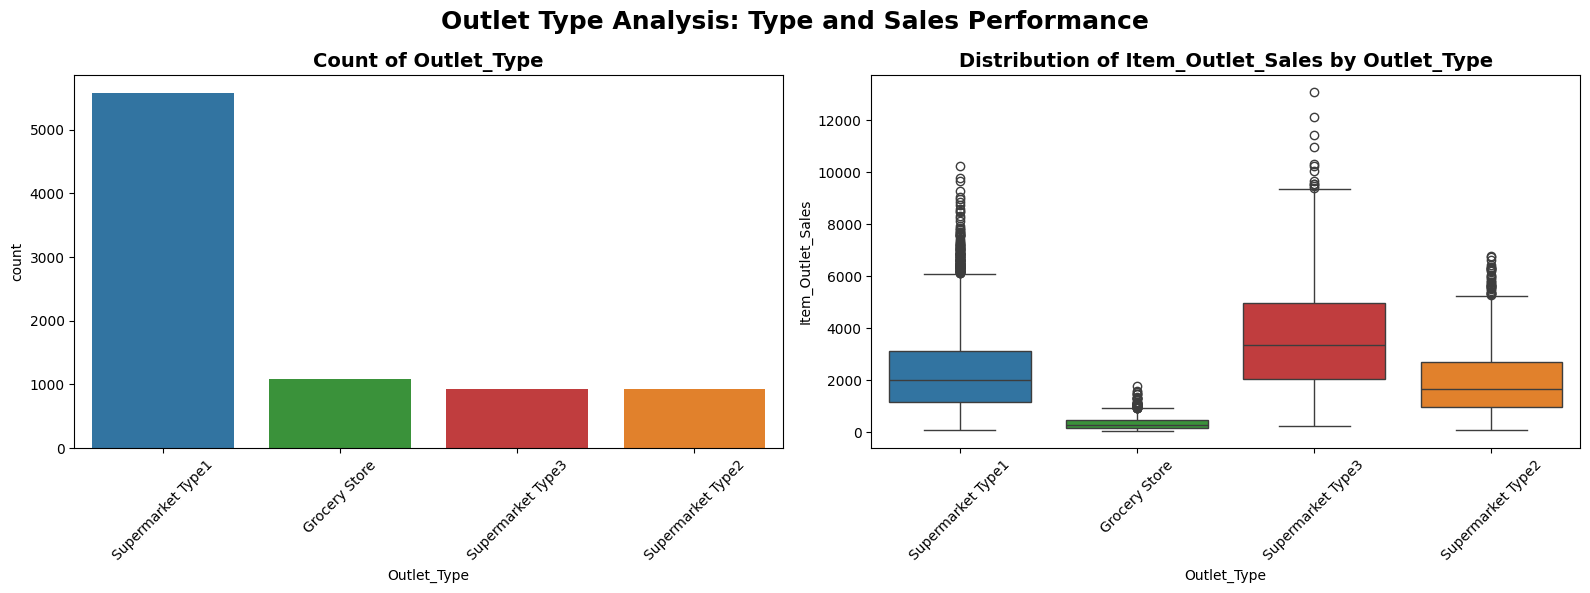

In [80]:
cat_analysis_plot(df_sales, x="Outlet_Type", y='Item_Outlet_Sales', title="Outlet Type Analysis: Type and Sales Performance") ;

- count plot demonstrates that 'Supermarket Type1' is the most frequent store type

- box plot highlights that 'Supermarket Type3' significantly outperforms other outlet types in median sales, despite having a lower number of stores compared to 'Supermarket Type1'.

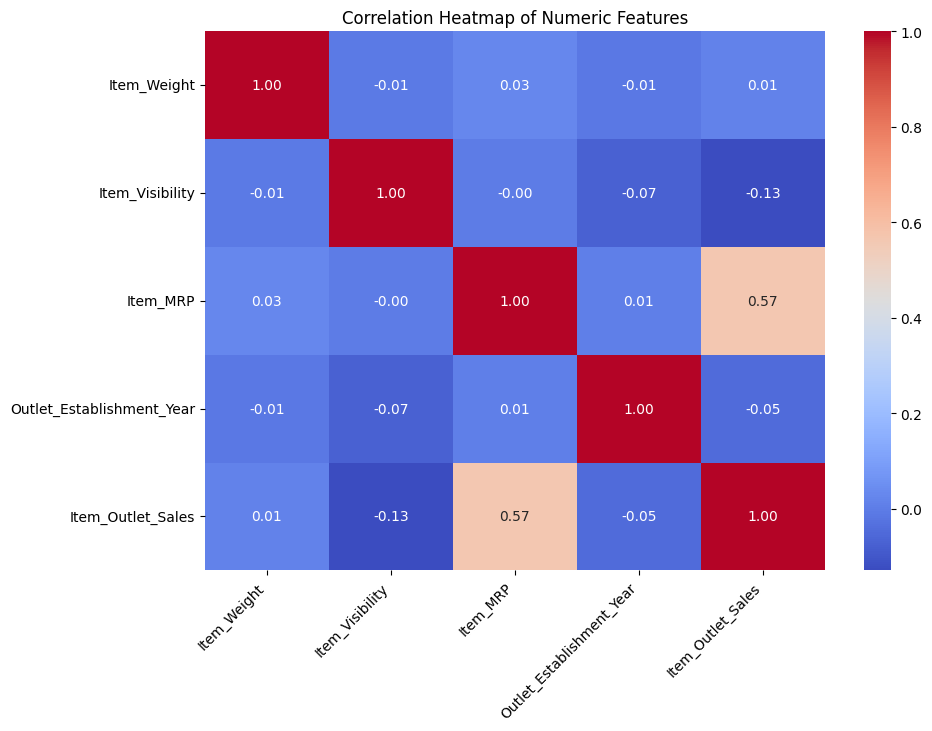

In [81]:
corr_matrix = df_sales.corr(numeric_only=True)

fig , ax = plt.subplots(figsize=(10,7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title("Correlation Heatmap of Numeric Features") ;


- There is a moderate positive correlation between Outlet Sales and Item MRP (0.57)
- All of the other correlations are negligible

## Feature Inspection